# Tennessee Eastman Process — Modellbildung

Lädt `data_campaign`/`data_production`/`data_error` aus *tep_generation*, wählt aus dem
Kampagnenpool eine Teilmenge von `N_CAMPAIGN` Betriebspunkten als Versuchskampagne,
trainiert darauf ein MLP mit fest vorgegebenem Merkmalssatz und validiert es auf den
Anfahrrampen derselben Punkte. Bewertet wird der Prädiktionsfehler auf den
Produktions- und Fehlerfalldaten, getrennt nach gesehenen und ungesehenen
Betriebspunkten und über deren Abstand zur Kampagne. Die gescorten Artefakte
`data_scored_production`/`data_scored_error` gehen an *tep_detection* und
*tep_adaptation*.

Die Screening-Zelle am Ende variiert Kampagnengröße und Validierungsschema; sie ist
Methodenarbeit und für den Hauptpfad nicht nötig.


In [6]:
FORCE_RECOMPUTE = False
IS_FINAL = True

In [7]:
# --- Konstanten ---
SEED = 42
RUN_ID = "1d772720" # None   # None -> neuester Produktionslauf
ERROR_VARIANT = {"idv": 29, "amp": 0.3}   # None -> neuester Fehlerfall
WINDOW_SIZE = 10
ARCH = [12, 12, 1]
ACT = "tanh"
EPOCHS = 200
BATCH = 200
PATIENCE = 20
VAL_SPLIT = 0.15

VAL_MODE = "ramp"       # "ramp" -> Anfahrrampen | "segment" -> ganze Betriebspunkte

SENSOR_FEATURE = "Stripper Temp"   # Wirkort der Kalibrierdrift IDV(29)
N_CAMPAIGN = 60                    # Betriebspunkte der Versuchskampagne
FEATURE_SET = ["Stripper Temp", "Purge valve", "Component E to Reactor",
               "Product Sep Temp", "MolePctGSP"]

SAMPLES_PER_H = 20
PLOT_FRAC = 0.1              # Anteil geplotteter Punkte
PLOT_YLIM = (-1e2, 1e2)      # symlog-Bereich der Fehlerachse
PLOT_EPOCH = "1970-01-01"    # Zeitstempel-Ursprung wie im synthetischen Fall

In [8]:
import tensorflow as tf   # muss zuerst geladen werden, sonst statische TLS-Slots erschöpft (DLL-Fehler 1114)
import os
from pathlib import Path

work_dir = os.getcwd()
DEFAULT_BASE_DIR = os.path.normpath(os.path.join(work_dir, "..", ".."))

base_dir = Path(os.environ.get("BASE_DIR", DEFAULT_BASE_DIR)).resolve()
data_dir = base_dir / "data" / "tep"
model_dir = base_dir / "models"
plot_dir = base_dir / "plots"
results_dir = base_dir / "results"

for _d in (data_dir, model_dir, plot_dir, results_dir):
    os.makedirs(_d, exist_ok=True)

In [9]:
import numpy as np

rng = np.random.default_rng(SEED)

## Daten laden

In [10]:
from src.utils import run_registry as rr
ledger = rr.run_ledger(work_dir)
data_store = rr.tep_data_store(data_dir)
model_store = rr.tep_model_store(model_dir)
plot_store = rr.tep_plot_store(plot_dir, ledger=ledger)
res_store = rr.tep_results_store(results_dir, ledger=ledger)

# base_cfg traegt data_campaign, production_cfg zusaetzlich data_production und data_error.
# rename=False bei allen drei Generierungs-Artefakten: sie stammen aus venv_37
# (pandas 1.3.5) und duerfen hier nicht neu geschrieben werden -- venv_37 koennte
# sie danach nicht mehr lesen. Die Schreibrichtung ist einbahnig: 37 schreibt, 311 liest.
prod_id = data_store.latest_id("data_production") if RUN_ID is None else RUN_ID
if prod_id is None:
    raise FileNotFoundError("Kein production-Artefakt. Bitte tep_generation.ipynb ausfuehren.")
production_data = data_store.load("data_production", run_id=prod_id, rename=False)
production_cfg = rr.RunConfig.from_document(production_data.attrs.get("config", production_data.attrs))

try:
    campaign_data = data_store.load("data_campaign", run_id=production_cfg.base_id, rename=False)
except FileNotFoundError:
    import glob as _g, os as _o, json as _j
    _av = []
    for _p in _g.glob(_o.path.join(str(data_dir), f"{data_store.prefix}_data_campaign_*.json")):
        with open(_p, encoding="utf-8") as _f:
            _av.append(_j.load(_f).get("id"))
    raise FileNotFoundError(
        f"Kampagnenartefakt zu base_id={production_cfg.base_id} fehlt. Vorhanden: {_av}. "
        "Der Produktionslauf gehoert dann zu einem anderen Versuchsplan -- "
        "tep_generation mit demselben Stand durchlaufen lassen.")
base_cfg = rr.RunConfig.from_document(campaign_data.attrs.get("config", campaign_data.attrs))

run_cfg = dict(base_cfg.document)
ramp_duration = run_cfg["ramp_h"]
soak_time = run_cfg["soak_h"]

error_data, error_cfg = rr.load_section(data_store, "data_error", production_cfg, "error",
                                        ERROR_VARIANT, rename=False)
error_variant = error_cfg.sections["error"]
ERROR_VARIANT_ID = error_variant["idv"]
if "driftf" not in error_data.columns:
    raise ValueError("data_error hat keine Spalte 'driftf'. Bitte die Zelle "
                     "'Gemessenes driftf als Spalte' in tep_generation ausfuehren.")

ledger.bind("model", parents={"production": production_cfg.id, "error": error_cfg.id})

print(f"base_id = {base_cfg.id} | run_id = {production_cfg.id} | error_run_id = {error_cfg.id} "
      f"(IDV {ERROR_VARIANT_ID}, amp {error_variant['amp']})")
print(f"Kampagnenpool {campaign_data['mode'].nunique()} Punkte, "
      f"Produktion {production_data['mode'].nunique()} Punkte, "
      f"Fehlerfall {error_data['mode'].nunique()} Punkte")

base_id = 818d4690 | run_id = 1d772720 | error_run_id = 90b92dbe (IDV 29, amp 0.3)
Kampagnenpool 136 Punkte, Produktion 122 Punkte, Fehlerfall 122 Punkte


## Vorverarbeitung

In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler


def preprocess(df: pd.DataFrame, scaler, fit: bool = False) -> pd.DataFrame:
    """Skalierung und Glaettung; Metadatenspalten bleiben unskaliert."""
    unchanged = [c for c in df.columns
                 if c in ["mode", "original_index", "reset", "status", "time",
                          "driftf", "drift_segment"]
                 or c.startswith("IDV")]
    numeric = df.drop(columns=unchanged)
    array = scaler.fit_transform(numeric) if fit else scaler.transform(numeric)
    scaled = pd.DataFrame(array, columns=numeric.columns, index=numeric.index)
    smoothed = scaled.rolling(window=WINDOW_SIZE, min_periods=1).mean()
    smoothed[unchanged] = df[unchanged]
    return smoothed

Skalierung und Glättung

In [12]:
scaler = MinMaxScaler()
campaign_smoothed_data = preprocess(campaign_data, scaler, fit=True)

Stationäre Bereiche wählen

In [13]:
def static_steady_mask(df: pd.DataFrame, ramp_duration: float, soak_time: float):
    mask = pd.Series(False, index=df.index)
    for mode in df["mode"].unique():
        mode_data = df[df["mode"] == mode]
        start_time = mode_data["time"].min() + ramp_duration
        end_time = start_time + soak_time - ramp_duration
        mask.loc[mode_data[(mode_data["time"] >= start_time) & (mode_data["time"] <= end_time)].index] = True

    return mask


def static_ramp_mask(df: pd.DataFrame, ramp_duration: float, skip: int = None):
    """Anfahrrampe je Block, ohne die ersten `skip` Zeilen der Blockgrenze."""
    skip = WINDOW_SIZE if skip is None else skip
    mask = pd.Series(False, index=df.index)
    for mode in df["mode"].unique():
        mode_data = df[df["mode"] == mode]
        t0 = mode_data["time"].min()
        sel = mode_data[(mode_data["time"] >= t0)
                        & (mode_data["time"] < t0 + ramp_duration)].index[skip:]
        mask.loc[sel] = True
    return mask

In [14]:
campaign_stationary_mask = static_steady_mask(campaign_smoothed_data,
                                              ramp_duration, soak_time)

In [15]:
def find_stationary_ranges(df_smoothed, stationary_mask, same_length:bool=True):
    stationary_changes = stationary_mask.astype(int).diff().fillna(0)
    starts = df_smoothed.index[stationary_changes == 1]
    ends = df_smoothed.index[stationary_changes == -1]

    # Edge cases
    if df_smoothed.index[stationary_mask][0] == df_smoothed.index[0]:
        starts = starts.insert(0, df_smoothed.index[0])
    if df_smoothed.index[stationary_mask][-1] == df_smoothed.index[-1]:
        ends = ends.append(pd.Index([df_smoothed.index[-1]]))

    stationary_ranges = list(zip(starts, ends))
    if not same_length:
        return stationary_ranges
    else:
        min_duration = min([end - start for start, end in stationary_ranges])
        stationary_ranges = [(start, start + min_duration) for start, end in stationary_ranges]
        return stationary_ranges

In [16]:
campaign_stationary_ranges = find_stationary_ranges(campaign_smoothed_data, campaign_stationary_mask, same_length=False)

In [17]:
campaign_means_all = pd.concat([campaign_smoothed_data.loc[(campaign_smoothed_data["original_index"]>=start) & 
                                      (campaign_smoothed_data["original_index"]<=end),:].mean(axis=0, numeric_only=True) 
                                      for start, end in campaign_stationary_ranges], axis=1).T

### Kampagne: Teilmenge der gefahrenen Punkte

`campaign_data` enthält alle fahrbaren Betriebspunkte. Trainiert wird nur auf einer Teilmenge — sonst hat das Modell jeden Produktionspunkt schon gesehen, jeder Abstand ist null und die Unterscheidung Kampagne/Produktion ist leer.

Die sechs Modusnennwerte sind gesetzt, der Rest wird per Maximin im skalierten Sollwertraum aufgefüllt: dokumentierte Rezepte plus möglichst weit gestreute Variationen. Auch Merkmalsauswahl und Korrelationen laufen ab hier nur noch auf der Kampagne — sonst flösse Wissen über die Produktionspunkte in das Modell ein.


In [18]:
from scipy.spatial.distance import cdist

campaign_means_all["mode"] = campaign_means_all["mode"].round().astype(int)
_range_modes = campaign_means_all["mode"].to_numpy()       # Reihenfolge = ranges
campaign_means_all = campaign_means_all.set_index("mode", drop=False)

setpoint_cols = [c for c in campaign_means_all.columns if c.endswith("SP")]
campaign_sp_scaled = campaign_means_all[setpoint_cols]
campaign_sp_scaled = ((campaign_sp_scaled - campaign_sp_scaled.min())
                      / (campaign_sp_scaled.max() - campaign_sp_scaled.min()).replace(0.0, 1.0))

def pick_campaign(n):
    """Modusnennwerte plus Maximin-Auffuellung im skalierten Sollwertraum."""
    sel = [int(m) for m in campaign_sp_scaled.index if m < 6]
    while len(sel) < n and len(sel) < len(campaign_sp_scaled):
        d = cdist(campaign_sp_scaled.to_numpy(),
                  campaign_sp_scaled.loc[sel].to_numpy()).min(axis=1)
        d[[campaign_sp_scaled.index.get_loc(m) for m in sel]] = -1.0
        sel.append(int(campaign_sp_scaled.index[int(np.argmax(d))]))
    return sel


def campaign_subset(modes):
    """(stationary_means, ranges) fuer eine Kampagnenauswahl."""
    return (campaign_means_all.loc[modes],
            [r for r, m in zip(campaign_stationary_ranges, _range_modes)
             if m in set(modes)])


campaign_modes = pick_campaign(N_CAMPAIGN)
stationary_means, campaign_ranges = campaign_subset(campaign_modes)

print(f"Kampagnenpool {len(campaign_means_all)} Punkte -> Kampagne {len(campaign_modes)}: "
      f"{sorted(campaign_modes)}")
print(f"  davon Modusnennwerte: {sorted(m for m in campaign_modes if m < 6)}")
_dm = cdist(campaign_sp_scaled.to_numpy(), campaign_sp_scaled.loc[campaign_modes].to_numpy()).min(axis=1)
print(f"  Abstand der uebrigen Poolpunkte zur Kampagne: Median {np.median(_dm):.3f}, "
      f"max {_dm.max():.3f} (skalierter Sollwertraum, 12 Dimensionen)")

Kampagnenpool 136 Punkte -> Kampagne 60: [0, 1, 2, 3, 4, 5, 11, 21, 22, 24, 26, 29, 35, 42, 55, 56, 60, 64, 69, 72, 78, 79, 84, 87, 90, 96, 103, 105, 113, 119, 121, 134, 146, 147, 156, 158, 179, 180, 184, 187, 195, 200, 206, 210, 211, 221, 237, 238, 255, 256, 259, 261, 269, 272, 279, 284, 286, 289, 290, 297]
  davon Modusnennwerte: [0, 1, 2, 3, 4, 5]
  Abstand der uebrigen Poolpunkte zur Kampagne: Median 0.564, max 0.804 (skalierter Sollwertraum, 12 Dimensionen)


Training vorbereiten

In [19]:
_unknown = [c for c in FEATURE_SET if c not in stationary_means.columns]
if _unknown:
    raise KeyError(f"FEATURE_SET enthaelt unbekannte Spalten: {_unknown}")
feature_cols = list(FEATURE_SET)
assert SENSOR_FEATURE in feature_cols, (
    "Wirkort der Sensordrift fehlt im Merkmalssatz")

print("Merkmalssatz:")
for _k, _c in enumerate(feature_cols, 1):
    print(f"  {_k}. {_c}")

Merkmalssatz:
  1. Stripper Temp
  2. Purge valve
  3. Component E to Reactor
  4. Product Sep Temp
  5. MolePctGSP


In [20]:
# Trainiert wird auf den Halteintervallen der Kampagnenpunkte.
campaign_preprocessed_data = pd.concat(
    [campaign_smoothed_data.loc[(campaign_smoothed_data["original_index"] >= start)
                                & (campaign_smoothed_data["original_index"] <= end), :]
     for start, end in campaign_ranges])

In [21]:
x_temp = campaign_preprocessed_data.loc[:, feature_cols].values
y_temp = campaign_preprocessed_data.loc[:, "cost"].values
segment = is_val = None

if VAL_MODE == "ramp":
    _camp = campaign_smoothed_data[campaign_smoothed_data["mode"].isin(campaign_modes)]
    _val = _camp[static_ramp_mask(_camp, ramp_duration)]
    x_train, y_train = x_temp, y_temp
    x_val = _val.loc[:, feature_cols].values
    y_val = _val.loc[:, "cost"].values
    n_val_points = int(_val["mode"].nunique())
elif VAL_MODE == "segment":
    segment = np.zeros(len(campaign_preprocessed_data), dtype=int)
    original_index = campaign_preprocessed_data["original_index"].to_numpy()
    for i, (start, end) in enumerate(campaign_ranges):
        segment[(original_index >= start) & (original_index <= end)] = i
    n_val = max(1, round(VAL_SPLIT * len(campaign_ranges)))
    val_segments = rng.choice(np.unique(segment), n_val, replace=False)
    is_val = np.isin(segment, val_segments)
    x_train, y_train = x_temp[~is_val], y_temp[~is_val]
    x_val, y_val = x_temp[is_val], y_temp[is_val]
    n_val_points = int(len(val_segments))
else:
    raise ValueError(f"VAL_MODE = {VAL_MODE!r}, erwartet 'ramp' oder 'segment'")

print(f"Validierung: {VAL_MODE}, {n_val_points} Betriebspunkte")
print(f"Train shape: {x_train.shape}, {y_train.shape}")
print(f"Validation shape: {x_val.shape}, {y_val.shape}")

Validierung: ramp, 60 Betriebspunkte
Train shape: (57706, 5), (57706,)
Validation shape: (57013, 5), (57013,)


## Neuronales Netz trainieren

In [22]:
model_params = {"arch": ARCH, "act": ACT, "opt": "adam", "epochs": EPOCHS,
                "batch": BATCH, "patience": PATIENCE, "val_split": VAL_SPLIT,
                "seed": SEED, "window_size": WINDOW_SIZE, "features": list(feature_cols),
                "val_mode": VAL_MODE, "sensor_feature": SENSOR_FEATURE,
                "n_campaign": len(campaign_modes)}

model_cfg = production_cfg.compose(model=model_params)
scored_error_cfg = model_cfg.compose(error=error_variant)

_model_loaded_from_cache = model_store.exists("model", model_cfg) and not FORCE_RECOMPUTE

In [23]:
if _model_loaded_from_cache:
    _mc = model_store.load("model", model_cfg, rename=True)
    model, feature_cols = _mc["model"], _mc["feature_cols"]
    print(f"Modell aus Cache | Early Stopping nach {_mc.get('epochs_run', '?')} Epochen")
    if _mc.get("loss_best"):
        print(f"  beste Epoche {_mc.get('best_epoch', '?')}: Trainingsverlust "
              f"{_mc['loss_best']:.3e}, Validierungsverlust {_mc['val_loss_best']:.3e}"
              f" (Verhaeltnis {_mc['val_loss_best'] / _mc['loss_best']:.1f})")
    else:
        print("  Verluste der besten Epoche nicht im Cache -- fuer Punkt 4 der"
              " Verbesserungsliste einmal mit FORCE_RECOMPUTE = True trainieren")
else:
    import tensorflow as tf
    from tensorflow import keras
    from keras import layers
    from keras.callbacks import EarlyStopping

    tf.keras.utils.set_random_seed(SEED)

    model = keras.Sequential(
        [layers.Input(shape=(len(feature_cols),))]
        + [layers.Dense(units, activation=ACT) for units in ARCH[:-1]]
        + [layers.Dense(ARCH[-1])]
    )

    model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    early_stop = EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True)

    history = model.fit(
        x_train, y_train, 
        validation_data=(x_val, y_val),
        epochs=EPOCHS, 
        batch_size=BATCH, 
        callbacks=[early_stop], 
        verbose=1
    )
    _epochs_run = len(history.history["loss"])
    # Punkt 4 der Verbesserungsliste: die Verluste der besten Epoche festhalten.
    # restore_best_weights greift auf argmin(val_loss). Liegt der Validierungs-
    # verlust um ein Vielfaches ueber dem Trainingsverlust, misst die Validierung
    # einen Sockel -- bei VAL_MODE = "ramp" die Transienten der Anfahrrampe, die
    # ein statisches Modell nicht abbilden kann -- und der Abbruch sagt dann wenig
    # ueber die Generalisierung auf ungesehene Betriebspunkte.
    _best_epoch = int(np.argmin(history.history["val_loss"]))
    _loss_best = float(history.history["loss"][_best_epoch])
    _val_loss_best = float(history.history["val_loss"][_best_epoch])
    print(f"Early Stopping nach {_epochs_run} von {EPOCHS} Epochen "
          f"(Validierung: {VAL_MODE}, {n_val_points} Betriebspunkte)")
    print(f"  beste Epoche {_best_epoch + 1}: Trainingsverlust {_loss_best:.3e}, "
          f"Validierungsverlust {_val_loss_best:.3e} "
          f"(Verhaeltnis {_val_loss_best / (_loss_best or np.nan):.1f})")
    model_store.save({"model": model, "feature_cols": list(feature_cols),
                      "window_size": WINDOW_SIZE, "epochs_run": _epochs_run,
                      "best_epoch": _best_epoch + 1, "loss_best": _loss_best,
                      "val_loss_best": _val_loss_best},
               "model", model_cfg)

Modell aus Cache | Early Stopping nach 155 Epochen
  beste Epoche 135: Trainingsverlust 5.290e-05, Validierungsverlust 1.187e-04 (Verhaeltnis 2.2)


In [24]:
if not _model_loaded_from_cache:
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(history.history['mae'], label='Train MAE')
    plt.plot(history.history['val_mae'], label='Val MAE')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## Produktions- und Fehlerdaten bewerten

Beide Strome durchlaufen dieselbe Kette: skalieren mit dem auf der Kampagne
gefitteten Scaler, glaetten, vorhersagen, Modellfehler anhaengen. Wird aus dem
Cache geladen, falls die Artefakte zur Modellkennung schon existieren.


In [25]:
def score(raw, cfg_, case):
    """Vorverarbeiten, vorhersagen, Modellfehler anhaengen -- oder aus dem Cache.

    Ausgewertet wird der vollstaendige Strom einschliesslich der Rampen; die
    Einschraenkung auf Halteintervalle geschieht ueber static_steady_mask.
    """
    if data_store.exists(case, cfg_) and not FORCE_RECOMPUTE:
        df = data_store.load(case, cfg_, rename=True)
        print(f"{case}: aus Cache ({len(df)} Zeilen)")
    else:
        df = preprocess(raw, scaler)
        df["y_pred"] = model.predict(
            df[feature_cols].to_numpy(dtype="float32", copy=False), verbose=0).ravel()
        df = df.set_index("original_index")
        data_store.save(df, case, cfg_, meta={"feature_cols": list(feature_cols)})
        print(f"{case}: gerechnet und gespeichert ({len(df)} Zeilen)")
    df["model_error"] = df["cost"] - df["y_pred"]
    return df


production_preprocessed_data = score(production_data, model_cfg,
                                     "data_scored_production")
error_preprocessed_data = score(error_data, scored_error_cfg, "data_scored_error")

data_scored_production: aus Cache (351361 Zeilen)
data_scored_error: aus Cache (351361 Zeilen)


## Vergleich Modellfehler: nominal vs. Fehlerfall

Stellt den Modellfehler des nominalen Testlaufs und des Fehlerfalls modeweise gegenüber,
normiert beide mit Mittelwert und Streuung des nominalen Testfehlers (identisch zu
*tep_detection*) und legt das rekonstruierte Driftsignal $c(t)$ auf die zweite Ordinate.

In [26]:
# Die Simulationszeit des Fehlerlaufs wird mitgefuehrt, sie argumentiert das
# Driftsignal und beginnt nach jedem Reset wieder bei 0.
combined = []

for mode in production_preprocessed_data["mode"].unique():
    production_temp = (production_preprocessed_data.loc[production_preprocessed_data["mode"] == mode,
                                            ["model_error"]]
                 .reset_index(drop=True))
    fault_temp = (error_preprocessed_data.loc[error_preprocessed_data["mode"] == mode,
                                              ["model_error", "time", "reset",
                                               "driftf", "drift_segment"]]
                  .reset_index(drop=True))
    combined.append(pd.concat([production_temp, fault_temp], axis=1))

combined_data = pd.concat(combined, axis=0, ignore_index=True)
combined_data.columns = ["model_error_normal", "model_error_fault",
                         "time_fault", "reset_fault", "driftf", "drift_segment"]


### Fehler normieren

Der Modellfehler wird mit Mittelwert und Streuung des nominalen Testfehlers normiert,
damit die Ordinate dieselbe Bedeutung hat wie im synthetischen Fall und in *tep_detection*.

In [27]:
_err_free = production_preprocessed_data["model_error"].to_numpy(dtype=float)
NORM_MEAN = float(np.nanmean(_err_free))
NORM_STD = float(np.nanstd(_err_free)) or 1.0

for _c in ("normal", "fault"):
    combined_data[f"error_norm_{_c}"] = (
        (combined_data[f"model_error_{_c}"] - NORM_MEAN) / NORM_STD)

# Darstellungszeit als Zeitstempel, analog syn_generation.
t_h = combined_data.index.to_numpy(dtype=float) / SAMPLES_PER_H
plot_index = pd.to_datetime(t_h * 3600.0, unit="s", origin=pd.Timestamp(PLOT_EPOCH))

_z = combined_data[["error_norm_normal", "error_norm_fault"]].to_numpy(dtype=float)
print(f"{len(combined_data)} Zeitschritte ({t_h[-1]:.0f} h, bis {plot_index[-1]:%d.%m.%Y}) | "
      f"Normierung: mean={NORM_MEAN:.4g}, std={NORM_STD:.4g}")
print(f"Norm. Fehler: max|z|={np.nanmax(np.abs(_z)):.1f}, "
      f"99.9%-Quantil={np.nanquantile(np.abs(_z), 0.999):.1f} "
      f"-> PLOT_YLIM ggf. anpassen")


351361 Zeitschritte (17568 h, bis 03.01.1972) | Normierung: mean=0.0005752, std=0.01314
Norm. Fehler: max|z|=18.6, 99.9%-Quantil=14.9 -> PLOT_YLIM ggf. anpassen


### Driftsignal

Das Driftsignal wird nicht mehr aus `DRIFT_PERIOD` rekonstruiert, sondern aus den Daten gelesen: `driftf` steht als Spalte in `data_error` und ist als Verhältnis der aufgezeichneten Strippertemperatur punktweise exakt. Damit hängt keine Auswertung mehr an einer C-Übersetzung, die nachweislich vom Simulator abweicht.


In [28]:
# driftf = Stripper Temp(Fehler) / Stripper Temp(nominal), aus tep_generation.
cd_signal = combined_data["driftf"].to_numpy(dtype=float) - 1.0

_seg = combined_data.groupby("drift_segment")["time_fault"].agg(["min", "max", "count"])
print(f"Driftsignal (gemessen): min={np.nanmin(cd_signal):.3f}, "
      f"max={np.nanmax(cd_signal):.3f} | "
      f"Kalibrierfaktor in [{1 + np.nanmin(cd_signal):.4f}, {1 + np.nanmax(cd_signal):.4f}]")
print(f"{len(_seg)} Driftsegmente:")
print(_seg.to_string(float_format=lambda v: f"{v:.1f}"))

Driftsignal (gemessen): min=-0.138, max=0.147 | Kalibrierfaktor in [0.8625, 1.1470]
12 Driftsegmente:
                  min     max  count
drift_segment                       
0                 0.0     0.0      1
1                 0.1  1693.7  33873
2              1693.7  3652.5  39177
3              3652.6  5390.1  34751
4              5390.1  7018.2  32563
5              7018.2  8623.0  32095
6              8623.0 10581.2  39165
7             10581.2 12216.0  32696
8             12216.1 14002.6  35731
9             14002.6 15613.9  32227
10            15614.0 17413.5  35993
11            17413.6 17568.0   3089


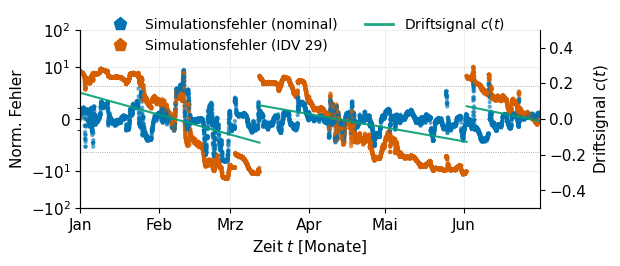

In [41]:
import matplotlib.pyplot as plt
from src.utils import thesis_style as ts

rng_plot = np.random.default_rng(SEED)

PLOT_MONTHS = 6   # None -> alles

_m = slice(None)
if PLOT_MONTHS is not None:
    _m = (plot_index < pd.Timestamp(PLOT_EPOCH) + pd.DateOffset(months=PLOT_MONTHS)).nonzero()[0]

fig, ax, ax2 = ts.error_timeseries(
    plot_index[_m],
    [(combined_data["error_norm_normal"].to_numpy(dtype=float)[_m],
      "drift_free", "Simulationsfehler (nominal)"),
     (combined_data["error_norm_fault"].to_numpy(dtype=float)[_m],
      "drift_afflicted", f"Simulationsfehler (IDV {ERROR_VARIANT_ID})")],
    cd=cd_signal[_m],
    ylabel="Norm. Fehler",
        xlabel="Zeit $t$ [Monate]",
        cd_label="Driftsignal $c(t)$",
        ylim=PLOT_YLIM, cd_amp=0.5, cd_tick_step=0.2,
        frac=PLOT_FRAC, rng=rng_plot, height_scale=0.45,
        legend=dict(bbox_to_anchor=[0.49, 1.15], loc="upper center", ncols=2, markerscale=1),
)
fig.tight_layout()
plot_store.save_figure(fig, "model_error", scored_error_cfg, final=IS_FINAL,
                       savefig_kwargs={"dpi": 300}, archive_kwargs={"dpi": 300})
plt.show()

## Numerische Auswertung der Modelldegradation

In [30]:
# Kennzahlen getrennt nach gesehenen und ungesehenen Betriebspunkten.
_seen = production_preprocessed_data["mode"].isin(campaign_modes).to_numpy()
_r0 = production_preprocessed_data["model_error"].to_numpy(dtype=float)
_r1 = error_preprocessed_data["model_error"].to_numpy(dtype=float)
_seen_e = error_preprocessed_data["mode"].isin(campaign_modes).to_numpy()

def _stats(a, b):
    return dict(rmse_free=np.sqrt(np.nanmean(a ** 2)),
                rmse_fault=np.sqrt(np.nanmean(b ** 2)),
                std_free=np.nanstd(a), bias_fault=np.nanmean(b),
                std_fault=np.nanstd(b),
                K=np.sqrt(np.nanmean(b ** 2)) / (np.sqrt(np.nanmean(a ** 2)) or np.nan))

# Die Zeilennamen gehen unveraendert in die LaTeX-Makronamen, daher nur Buchstaben.
stats = pd.DataFrame({
    "Alle": _stats(_r0, _r1),
    "Ungesehen": _stats(_r0[~_seen], _r1[~_seen_e]),
    "Gesehen": _stats(_r0[_seen], _r1[_seen_e]),
}).T
pd.set_option("display.float_format", lambda v: f"{v:.4g}")
print(stats.to_string())
print(f"\n{int((~_seen).sum())} von {len(_seen)} Zeilen auf ungesehenen Punkten "
      f"({production_preprocessed_data.loc[~_seen, 'mode'].nunique()} Betriebspunkte)")

r0, r1 = _r0[~_seen], _r1[~_seen_e]

           rmse_free  rmse_fault  std_free  bias_fault  std_fault     K
Alle         0.01315     0.05704   0.01314   -0.009028    0.05632 4.337
Ungesehen    0.01529     0.05448   0.01526    -0.01848    0.05125 3.563
Gesehen     0.009684      0.0602  0.009683    0.003275    0.06011 6.217

198720 von 351361 Zeilen auf ungesehenen Punkten (69 Betriebspunkte)


## Modellfehler über dem Abstand zur Kampagne

Der eigentliche Ertrag der modusweisen Datengrundlage. Für jeden Produktionspunkt der Abstand zum nächsten Kampagnenpunkt im skalierten Sollwertraum gegen den Modellfehler. Daraus wird begründet, bis zu welcher Abweichung vom Versuchsplan der Drift sichtbar bleibt — statt diese Grenze zu setzen.


In [31]:
# Abstand wahlweise im Sollwert- oder im Merkmalsraum.
DIST_SPACE = "feature"        # "feature" | "setpoint"

_pm = static_steady_mask(production_preprocessed_data, ramp_duration, soak_time)
_em = static_steady_mask(error_preprocessed_data, ramp_duration, soak_time)
_ph, _eh = production_preprocessed_data[_pm], error_preprocessed_data[_em]

_rms = lambda s: float(np.sqrt(np.nanmean(np.asarray(s, float) ** 2)))
point = pd.DataFrame({
    "err_free": _ph.groupby("mode")["model_error"].apply(_rms),
    "err_fault": _eh.groupby("mode")["model_error"].apply(_rms),
    "cost": _ph.groupby("mode")["cost"].mean(),
})
point["d_e"] = (_eh.groupby("mode")["model_error"].mean()
                - _ph.groupby("mode")["model_error"].mean()).abs()
point["gesehen"] = point.index.isin(campaign_modes)


def _min_dist(cols):
    """Abstand je Produktionspunkt zum naechsten Kampagnenpunkt, skaliert auf
    die Spannweite des Kampagnenpools."""
    lo, hi = campaign_means_all[cols].min(), campaign_means_all[cols].max()
    span = (hi - lo).replace(0.0, 1.0)
    up = (_ph.groupby("mode")[cols].mean() - lo) / span
    uc = (campaign_means_all.loc[campaign_modes, cols] - lo) / span
    return cdist(up.to_numpy(), uc.to_numpy()).min(axis=1)


point["dist_sp"] = _min_dist(setpoint_cols)
point["dist_feat"] = _min_dist(list(feature_cols))
_dcol = "dist_feat" if DIST_SPACE == "feature" else "dist_sp"

print(f"{len(point)} Produktionspunkte, davon {int(point['gesehen'].sum())} gesehen")
print(f"Abstand Sollwertraum ({len(setpoint_cols)}D): "
      f"{point['dist_sp'].min():.3f} .. {point['dist_sp'].max():.3f}")
print(f"Abstand Merkmalsraum ({len(feature_cols)}D): "
      f"{point['dist_feat'].min():.3f} .. {point['dist_feat'].max():.3f}")
_ung = ~point["gesehen"]
for _c in ("dist_sp", "dist_feat"):
    print(f"  corr(err_free, {_c:9s}) ueber die ungesehenen Punkte = "
          f"{np.corrcoef(point.loc[_ung, _c], point.loc[_ung, 'err_free'])[0, 1]:+.3f}")

print("\nZerlegung von RMSE_frei:")
for _lab, _sel in (("gesehen (Abstand 0)", point["gesehen"]), ("ungesehen", _ung)):
    if _sel.any():
        print(f"  {_lab:22s} n={int(_sel.sum()):3d}  RMSE {_rms(point.loc[_sel, 'err_free']):7.4f}"
              f"  Abstand Median {point.loc[_sel, _dcol].median():.3f}")

_edges = np.quantile(point.loc[_ung, _dcol], np.linspace(0, 1, 6))
_edges[0], _edges[-1] = _edges[0] - 1e-9, _edges[-1] + 1e-9
point["klasse"] = pd.cut(point[_dcol], np.unique(_edges))
_curve = point.groupby("klasse", observed=True).agg(
    n=("err_free", "size"), abstand=(_dcol, "median"),
    rmse_frei=("err_free", _rms), d_e=("d_e", "mean"))
_curve["verhaeltnis"] = _curve["d_e"] / _curve["rmse_frei"]
print(f"\nAbstandsklassen im {DIST_SPACE}-Raum:")
print(_curve.to_string(float_format=lambda v: f"{v:.4f}"))
print("\nverhaeltnis > 1 heisst: die driftbedingte Verschiebung uebersteigt den")
print("nominalen Fehler -- ab dort ist der Drift im Modellfehler sichtbar.")

# Zuwachs des nominalen Fehlers ueber den Abstandsbereich, Makro tepstatDistGrowth.
dist_growth = float(_curve["rmse_frei"].iloc[-1] / _curve["rmse_frei"].iloc[0])
print(f"\nnominaler Fehler waechst ueber die Abstandsklassen um Faktor {dist_growth:.2f}")


122 Produktionspunkte, davon 53 gesehen
Abstand Sollwertraum (12D): 0.000 .. 0.804
Abstand Merkmalsraum (5D): 0.000 .. 0.364
  corr(err_free, dist_sp  ) ueber die ungesehenen Punkte = +0.107
  corr(err_free, dist_feat) ueber die ungesehenen Punkte = +0.258

Zerlegung von RMSE_frei:
  gesehen (Abstand 0)    n= 53  RMSE  0.0070  Abstand Median 0.001
  ungesehen              n= 69  RMSE  0.0187  Abstand Median 0.142

Abstandsklassen im feature-Raum:
                   n  abstand  rmse_frei    d_e  verhaeltnis
klasse                                                      
(0.0304, 0.0747]  14   0.0538     0.0110 0.0388       3.5347
(0.0747, 0.128]   15   0.0927     0.0115 0.0355       3.0982
(0.128, 0.159]    13   0.1420     0.0178 0.0283       1.5900
(0.159, 0.202]    14   0.1721     0.0222 0.0518       2.3298
(0.202, 0.364]    14   0.2407     0.0259 0.0646       2.4951

verhaeltnis > 1 heisst: die driftbedingte Verschiebung uebersteigt den
nominalen Fehler -- ab dort ist der Drift im Model

In [32]:
## Driftwirkung je Segment
_seg_tbl = (combined_data.groupby("drift_segment")
            .agg(n=("model_error_fault", "size"),
                 t_min=("time_fault", "min"), t_max=("time_fault", "max"),
                 driftf_min=("driftf", "min"), driftf_max=("driftf", "max"),
                 rmse_frei=("model_error_normal", _rms),
                 rmse_fehler=("model_error_fault", _rms)))
_seg_tbl["K"] = _seg_tbl["rmse_fehler"] / _seg_tbl["rmse_frei"]
print(_seg_tbl.to_string(float_format=lambda v: f"{v:.3f}"))

# Korrelation der Fehlerverschiebung mit dem Driftsignal, je Segment
print("\nKorrelation (Fehlerdifferenz, driftf) je Segment:")
for _s, _g in combined_data.groupby("drift_segment"):
    _dy = (_g["model_error_fault"] - _g["model_error_normal"]).to_numpy(dtype=float)
    _ok = np.isfinite(_dy) & np.isfinite(_g["driftf"].to_numpy(dtype=float))
    if _ok.sum() > 10:
        print(f"  Segment {int(_s)}: n={int(_ok.sum()):6d}  "
              f"corr = {np.corrcoef(_dy[_ok], _g['driftf'].to_numpy(float)[_ok])[0, 1]:+.3f}")

                   n     t_min     t_max  driftf_min  driftf_max  rmse_frei  rmse_fehler      K
drift_segment                                                                                  
0                  1     0.000     0.000       1.000       1.000      0.001        0.001  1.000
1              33873     0.050  1693.650       0.868       1.147      0.020        0.079  3.918
2              39177  1693.700  3652.500       0.872       1.077      0.009        0.063  6.787
3              34751  3652.550  5390.050       0.862       1.072      0.011        0.063  5.917
4              32563  5390.100  7018.200       0.879       1.063      0.011        0.058  5.473
5              32095  7018.250  8622.950       0.877       1.074      0.012        0.059  4.895
6              39165  8623.000 10581.200       0.933       1.055      0.013        0.031  2.360
7              32696 10581.250 12216.000       0.917       1.092      0.018        0.040  2.240
8              35731 12216.050 14002.550

## Zerlegung des Modellfehlers nach Betriebsphase

Ein Modusblock dauert `ramp_duration + soak_time` = 144 h und besteht aus drei Teilen: der Anfahrrampe auf den Sollwert (`ramp_duration`, die erste Hälfte von `soak_time`), dem eigentlichen Halteintervall, und der Rückrampe zu Mode 1, mit der `run_simulation` jeden Block abschließt. Alle drei tragen dieselbe `mode`-Kennung, `static_steady_mask` greift den mittleren Teil heraus.

Trainiert wird nur auf den Halteintervallen der Kampagne, bewertet wird der vollständige Strom — und die Adaption läuft ebenfalls darauf. Die Tabelle stellt den Zeilenanteil jeder Phase ihrem Anteil am mittleren quadratischen Fehler gegenüber. *Blockanfang* sind die `WINDOW_SIZE` Zeilen, in denen die gleitende Mittelung noch den Vorgängerblock mitführt.

In [33]:
# Zerlegung des Modellfehlers nach Betriebsphase. Vorabauswertung zu Punkt 1 der
# Verbesserungsliste: trainiert wird nur auf Halteintervallen, bewertet wird der
# vollstaendige Strom. Traegt eine der Rampen den Fehler, ist das der Beleg dafuer.
_ORDER = ["Blockanfang", "Anfahrrampe", "Halt", "Rueckrampe"]


def phase_labels(df):
    """Betriebsphase je Zeile.

    Der Block laeuft ueber ramp_duration + soak_time = 144 h: Anfahrrampe
    [t0, t0 + ramp_duration), Halteintervall [t0 + ramp_duration, t0 + soak_time]
    und Rueckrampe zu Mode 1 bis zum Blockende, alle unter derselben mode-Kennung.
    'Blockanfang' sind die WINDOW_SIZE Zeilen, in denen die Glaettung noch den
    Vorgaengerblock mitfuehrt.
    """
    lab = pd.Series("Rueckrampe", index=df.index)
    lab[static_ramp_mask(df, ramp_duration)] = "Anfahrrampe"
    lab[static_steady_mask(df, ramp_duration, soak_time)] = "Halt"
    head = pd.Series(False, index=df.index)
    for _m in df["mode"].unique():
        head.loc[df.index[df["mode"] == _m][:WINDOW_SIZE]] = True
    lab[head] = "Blockanfang"
    return lab


_lab_p = phase_labels(production_preprocessed_data)
_lab_e = phase_labels(error_preprocessed_data)


def _phase_table(sel_p=None, sel_e=None):
    """Kennzahlen je Phase; sel_* schraenkt auf eine Zeilenteilmenge ein."""
    ep = production_preprocessed_data["model_error"].to_numpy(dtype=float)
    ee = error_preprocessed_data["model_error"].to_numpy(dtype=float)
    lp, le = _lab_p.to_numpy(), _lab_e.to_numpy()
    if sel_p is not None:
        ep, lp, ee, le = ep[sel_p], lp[sel_p], ee[sel_e], le[sel_e]
    mse_ges = float(np.nanmean(ep ** 2))
    rows = {}
    for ph in _ORDER:
        a, b = ep[lp == ph], ee[le == ph]
        if not len(a):
            continue
        rows[ph] = dict(n=len(a), anteil=len(a) / len(ep),
                        rmse_frei=_rms(a), rmse_fehler=_rms(b),
                        K=_rms(b) / (_rms(a) or np.nan),
                        mse_anteil=len(a) * float(np.nanmean(a ** 2)) / (len(ep) * mse_ges))
    out = pd.DataFrame(rows).T
    out.loc["gesamt"] = dict(n=len(ep), anteil=1.0, rmse_frei=_rms(ep),
                             rmse_fehler=_rms(ee), K=_rms(ee) / (_rms(ep) or np.nan),
                             mse_anteil=1.0)
    return out


_fmt = lambda v: f"{v:.4f}"
print("Modellfehler nach Betriebsphase, alle Produktionspunkte:")
print(_phase_table().to_string(float_format=_fmt))

_sel_p = ~production_preprocessed_data["mode"].isin(campaign_modes).to_numpy()
_sel_e = ~error_preprocessed_data["mode"].isin(campaign_modes).to_numpy()
print("\nnur ungesehene Betriebspunkte:")
print(_phase_table(_sel_p, _sel_e).to_string(float_format=_fmt))

# Was von RMSE_frei bliebe, wenn nur im Halt bewertet wuerde.
_e_all = production_preprocessed_data["model_error"].to_numpy(dtype=float)
_e_ramp = _e_all[np.isin(_lab_p.to_numpy(), ["Anfahrrampe", "Rueckrampe"])]
_e_hold = _e_all[_lab_p.to_numpy() == "Halt"]
print(f"\nRMSE_frei gesamt {_rms(_e_all):.4f} | nur Halt {_rms(_e_hold):.4f}"
      f" | nur Rampen {_rms(_e_ramp):.4f}"
      f" | Verhaeltnis {_rms(_e_ramp) / (_rms(_e_hold) or np.nan):.2f}")
print("Beide Rampen laufen zwischen Mode 1 und dem Betriebspunkt, durchqueren also")
print("trainiertes Gebiet. Liegt ihr MSE-Anteil unter dem Zeilenanteil, sitzt der")
print("nominale Fehler im Halt auf dem ungesehenen Punkt und nicht in den Rampen --")
print("Punkt 1 der Verbesserungsliste greift dann nicht.")

Modellfehler nach Betriebsphase, alle Produktionspunkte:
                      n  anteil  rmse_frei  rmse_fehler      K  mse_anteil
Blockanfang   1220.0000  0.0035     0.0078       0.0472 6.0342      0.0012
Anfahrrampe 115902.0000  0.3299     0.0118       0.0551 4.6789      0.2645
Halt        117239.0000  0.3337     0.0148       0.0619 4.1893      0.4210
Rueckrampe  117000.0000  0.3330     0.0128       0.0539 4.2213      0.3133
gesamt      351361.0000  1.0000     0.0132       0.0570 4.3366      1.0000

nur ungesehene Betriebspunkte:
                      n  anteil  rmse_frei  rmse_fehler      K  mse_anteil
Blockanfang    690.0000  0.0035     0.0092       0.0448 4.8811      0.0012
Anfahrrampe  65551.0000  0.3299     0.0122       0.0525 4.3124      0.2088
Halt         66307.0000  0.3337     0.0187       0.0604 3.2378      0.4969
Rueckrampe   66172.0000  0.3330     0.0143       0.0501 3.4913      0.2930
gesamt      198720.0000  1.0000     0.0153       0.0545 3.5628      1.0000

RMSE_frei 

## Realisierte Driftempfindlichkeit

*tep_generation* legt die Fehleramplitude über eine lineare Empfindlichkeit von 4,4 Kosteneinheiten je Prozent Kalibrierfehler aus. Ob das Netz diese Empfindlichkeit auch abbildet, ist bisher nicht gemessen worden. Verglichen werden drei Größen: die Verschiebung der Vorhersage, wenn der Sensor um den tatsächlich gefahrenen Kalibrierfehler verstellt wird, der Gradient $\partial\hat{y}/\partial$ `Stripper Temp` an den Betriebspunktmitteln, und der Beitrag jedes Merkmals im Permutationstest.

Fällt die realisierte Empfindlichkeit deutlich kleiner aus als die lineare Referenz, verteilt das Netz die Temperaturinformation auf die korrelierten Eingänge. Der Drift wird dann durch Redundanz im Merkmalssatz maskiert und $K$ ist niedriger, als der Wirkort hergibt; die Korrelationsmatrix am Ende ist die Gegenprobe dazu.

In [34]:
# Realisierte Driftempfindlichkeit des Netzes am Wirkort der Kalibrierdrift
# (Punkt 2 der Verbesserungsliste). Referenz ist die lineare Empfindlichkeit aus
# tep_generation, mit der dort die Fehleramplitude ausgelegt wurde. Reine
# Auswertung auf dem vorhandenen Modell, kein Training.
SENS_PER_PCT = 4.4        # tep_generation: Kosteneinheiten je Prozent Kalibrierfehler
T_STRIPPER_NOM = 60.2     # tep_generation: mittlere Strippertemperatur in Grad C

# Der MinMaxScaler ist affin (x_roh = x_skal * range + min), damit laesst sich der
# multiplikative Kalibrierfehler ohne Rueckgriff auf die Rohdaten in den skalierten
# Raum ziehen: ein Fehler p bedeutet x_skal -> x_skal + p * (x_skal + min/range).
_sc_range = pd.Series(scaler.data_range_, index=scaler.feature_names_in_)
_sc_min = pd.Series(scaler.data_min_, index=scaler.feature_names_in_)
SPAN_COST = float(_sc_range["cost"])
_off_sens = float(_sc_min[SENSOR_FEATURE]) / float(_sc_range[SENSOR_FEATURE])
_j_sens = list(feature_cols).index(SENSOR_FEATURE)

# Auswertungsbasis: Halteintervalle des nominalen Produktionsstroms.
_hold_mask = static_steady_mask(production_preprocessed_data, ramp_duration, soak_time)
_hold = production_preprocessed_data[_hold_mask]
_Xh = _hold[list(feature_cols)].to_numpy("float32")
_yh = _hold["cost"].to_numpy(dtype=float)
_y0 = model.predict(_Xh, verbose=0).ravel()

_t_raw = (float(np.mean(_Xh[:, _j_sens])) * float(_sc_range[SENSOR_FEATURE])
          + float(_sc_min[SENSOR_FEATURE]))
print(f"Kostenspanne der Kampagne: {SPAN_COST:.1f} Kosteneinheiten je skalierter Einheit")
print(f"  nominaler RMSE im Halt {_rms(_y0 - _yh):.4f} skaliert = "
      f"{_rms(_y0 - _yh) * SPAN_COST:.1f} Kosteneinheiten")
print(f"mittlere {SENSOR_FEATURE}: {_t_raw:.1f} "
      f"(tep_generation rechnet mit {T_STRIPPER_NOM})")

# --- 1) Finite Differenz mit dem tatsaechlich gefahrenen Kalibrierfehler ---
_cal = error_preprocessed_data["driftf"].to_numpy(dtype=float) - 1.0
_p_rms = float(np.sqrt(np.nanmean(_cal ** 2)))
_p_peak = float(np.nanmax(np.abs(_cal)))


def _shifted_pred(p):
    """Vorhersage, wenn der Sensor um den Faktor (1 + p) fehlkalibriert ist."""
    Z = _Xh.copy()
    Z[:, _j_sens] = Z[:, _j_sens] + np.float32(p) * (Z[:, _j_sens] + np.float32(_off_sens))
    return model.predict(Z, verbose=0).ravel()


print(f"\nGefahrener Kalibrierfehler: Effektivwert {100 * _p_rms:.1f} %, "
      f"Spitze {100 * _p_peak:.1f} %")
print(f"{'':14s}{'Fehler':>6} {'erwartet':>10} {'realisiert':>11} {'Anteil':>8}")
for _p, _tag in ((_p_rms, "Effektivwert"), (_p_peak, "Spitzenwert")):
    _dy = (_shifted_pred(_p) - _y0) * SPAN_COST
    _exp = 100 * _p * SENS_PER_PCT
    _got = float(np.mean(np.abs(_dy)))
    print(f"{_tag:12s} {100 * _p:5.1f} % {_exp:10.1f} {_got:11.1f} {_got / _exp:8.2f}")
print("erwartet = lineare Empfindlichkeit aus tep_generation, realisiert = mittlere")
print("Betragsverschiebung der Modellvorhersage. Ein Anteil deutlich unter 1 heisst:")
print("das Netz gibt die Temperaturinformation nicht voll an den Ausgang weiter.")

# --- 2) Gradient an den Betriebspunktmitteln ---
_means = _hold.groupby("mode")[list(feature_cols)].mean()
_x_in = tf.convert_to_tensor(_means.to_numpy("float32"))
with tf.GradientTape() as _tape:
    _tape.watch(_x_in)
    _y_out = model(_x_in, training=False)
_grad = pd.DataFrame(np.asarray(_tape.gradient(_y_out, _x_in)), index=_means.index,
                     columns=list(feature_cols))

# Gradient am Wirkort, umgerechnet in Kosteneinheiten je Prozent Kalibrierfehler.
_sens_pt = (_grad[SENSOR_FEATURE].to_numpy(dtype=float)
            * 0.01 * (_means[SENSOR_FEATURE].to_numpy(dtype=float) + _off_sens)
            * SPAN_COST)
_qs = np.nanpercentile(_sens_pt, [10, 50, 90])
print(f"\nGradient d(cost)/d(Kalibrierfehler) ueber {len(_means)} Betriebspunkte:")
print(f"  Median {_qs[1]:+.2f}, Dezile {_qs[0]:+.2f} .. {_qs[2]:+.2f} "
      f"Kosteneinheiten je Prozent (Referenz {SENS_PER_PCT})")
print(f"  {int(np.sum(_sens_pt < 0))} von {len(_sens_pt)} Punkten mit umgekehrtem Vorzeichen")

# --- 3) Beitrag der einzelnen Merkmale: Gradient und Permutation ---
_rng_perm = np.random.default_rng(SEED)
_imp = pd.DataFrame({"grad_abs": _grad.abs().mean(), "grad_median": _grad.median()})
_base_rmse = _rms(_y0 - _yh)
_perm = {}
for _k, _name in enumerate(feature_cols):
    Z = _Xh.copy()
    Z[:, _k] = Z[_rng_perm.permutation(len(Z)), _k]
    _perm[_name] = _rms(model.predict(Z, verbose=0).ravel() - _yh) / _base_rmse
_imp["perm_rmse_x"] = pd.Series(_perm)
print(f"\nMerkmalsbeitraege (Permutation als Vielfaches von RMSE {_base_rmse:.4f}):")
print(_imp.to_string(float_format=lambda v: f"{v:+.3f}"))

# --- 4) Kollinearitaet im Merkmalssatz, auf der Kampagne gerechnet ---
print("\nKorrelation der Merkmale auf den Kampagnen-Halteintervallen:")
print(campaign_preprocessed_data[list(feature_cols)].corr()
      .to_string(float_format=lambda v: f"{v:+.2f}"))
print("\nIst der realisierte Anteil klein und stehen andere Merkmale stark mit")
print(f"{SENSOR_FEATURE} in Beziehung, wird der Drift durch Redundanz maskiert --")
print("dann ist der Merkmalssatz zu pruefen, nicht der Wirkort.")

Kostenspanne der Kampagne: 1051.2 Kosteneinheiten je skalierter Einheit
  nominaler RMSE im Halt 0.0148 skaliert = 15.5 Kosteneinheiten
mittlere Stripper Temp: 62.9 (tep_generation rechnet mit 60.2)

Gefahrener Kalibrierfehler: Effektivwert 6.1 %, Spitze 14.7 %
              Fehler   erwartet  realisiert   Anteil
Effektivwert   6.1 %       26.7        55.7     2.08
Spitzenwert   14.7 %       64.7       128.7     1.99
erwartet = lineare Empfindlichkeit aus tep_generation, realisiert = mittlere
Betragsverschiebung der Modellvorhersage. Ein Anteil deutlich unter 1 heisst:
das Netz gibt die Temperaturinformation nicht voll an den Ausgang weiter.

Gradient d(cost)/d(Kalibrierfehler) ueber 122 Betriebspunkte:
  Median -9.88, Dezile -12.55 .. -5.19 Kosteneinheiten je Prozent (Referenz 4.4)
  122 von 122 Punkten mit umgekehrtem Vorzeichen

Merkmalsbeitraege (Permutation als Vielfaches von RMSE 0.0148):
                        grad_abs  grad_median  perm_rmse_x
Stripper Temp             +1.045 

## Kalibrierung für tep_generation

Schreibt die drei Größen, mit denen `tep_generation` die Driftamplitude auslegt, nach `results/tep_model_calibration.json`: die mittlere Strippertemperatur, die realisierte Empfindlichkeit am Wirkort und das Rauschen des Modellfehlers innerhalb eines Betriebspunkts. Die Datei geht weder in einen Hash noch ins Ledger ein.

In [35]:
import json

_noise_pt = _hold.groupby("mode")["model_error"].std().to_numpy(dtype=float)

calibration = {
    "t_stripper_nom": round(float(_t_raw), 2),
    "sens_per_pct": round(abs(float(np.nanmedian(_sens_pt))), 2),
    "noise_floor": round(float(np.nanmedian(_noise_pt)) * SPAN_COST, 2),
    "span_cost": round(SPAN_COST, 1),
    "sensor_feature": SENSOR_FEATURE,
    "model": model_cfg.id,
    "production": production_cfg.id,
    "error": error_cfg.id,
}

_cal_path = Path(results_dir) / "tep_model_calibration.json"
with open(_cal_path, "w", encoding="utf-8") as _f:
    json.dump(calibration, _f, indent=2)

print(json.dumps(calibration, indent=2))
print(f"-> {_cal_path}")

{
  "t_stripper_nom": 62.94,
  "sens_per_pct": 9.88,
  "noise_floor": 1.68,
  "span_cost": 1051.2,
  "sensor_feature": "Stripper Temp",
  "model": "8165f7ca",
  "production": "1d772720",
  "error": "90b92dbe"
}
-> C:\git\process_optimization_concept_drift\results\tep_model_calibration.json


## Ergebnisse speichern

In [36]:
from src.utils import results_export as rx

_keys = [(k, k, "num") for k in
         ["rmse_free", "rmse_fault", "std_free", "bias_fault", "std_fault"]]

(rx.ResultDoc()
   .integer("n_test", len(production_preprocessed_data))
   .integer("n_error", len(error_preprocessed_data))
   .integer("n_campaign", model_params["n_campaign"])
   .integer("n_layers", len(model_params["arch"]))
   .integer("n_neurons", model_params["arch"][0])
   .integer("n_epochs", model_params["epochs"])
   .integer("batch_size", model_params["batch"])
   .integer("window_size", model_params["window_size"])
   .stats(stats, _keys, into="models")
   .save(res_store, "model_error", scored_error_cfg, final=IS_FINAL))

Umfassende Ergebnisse -> C:\git\process_optimization_concept_drift\results\tep_model_error.json


'C:\\git\\process_optimization_concept_drift\\results\\tep_model_error.json'

In [37]:
from src.utils import latex_export as lx

mx = lx.MacroExport("automatisch erzeugt aus tep_model.ipynb - nicht manuell editieren")

mx.comment("Parameter (Hash-relevant, Sektion 'model')")
mx.param("tepParamWindow", model_params["window_size"])
mx.param("tepParamEpochs", model_params["epochs"])
mx.param("tepParamBatch", model_params["batch"])
mx.param("tepParamPatience", model_params["patience"])
mx.param("tepParamValSplitPct", round(model_params["val_split"] * 100))
mx.param("tepParamNeurons", model_params["arch"][0])
mx.param("tepParamNLayers", len(model_params["arch"]) - 1, spell_out=True)
mx.param("tepParamNFeatures", len(model_params["features"]), spell_out=True)
mx.param("tepParamNCampaign", model_params["n_campaign"])

mx.comment("Ergebnisse (Modellfehler-Statistiken)")
mx.stats(stats, [("rmse_free", "RmseFree", 3), ("rmse_fault", "RmseFault", 3),
                 ("std_free", "SigmaFree", 3), ("bias_fault", "Bias", 3),
                 ("std_fault", "Sigma", 3), ("K", "K", 3)], prefix="tepstat")

mx.comment("Abstandsanalyse")
mx.num("tepstatDistGrowth", dist_growth, 1)

mx.save(res_store, "model_error", scored_error_cfg, final=IS_FINAL)


LaTeX-Makros -> C:\git\process_optimization_concept_drift\results\tep_model_error.tex

% automatisch erzeugt aus tep_model.ipynb - nicht manuell editieren

% Parameter (Hash-relevant, Sektion 'model')
\newcommand{\tepParamWindow}{10}
\newcommand{\tepParamEpochs}{200}
\newcommand{\tepParamBatch}{200}
\newcommand{\tepParamPatience}{20}
\newcommand{\tepParamValSplitPct}{15}
\newcommand{\tepParamNeurons}{12}
\newcommand{\tepParamNLayers}{zwei}
\newcommand{\tepParamNFeatures}{fünf}
\newcommand{\tepParamNCampaign}{60}

% Ergebnisse (Modellfehler-Statistiken)
\newcommand{\tepstatAlleRmseFree}{0{,}013}
\newcommand{\tepstatAlleRmseFault}{0{,}057}
\newcommand{\tepstatAlleSigmaFree}{0{,}013}
\newcommand{\tepstatAlleBias}{-0{,}009}
\newcommand{\tepstatAlleSigma}{0{,}056}
\newcommand{\tepstatAlleK}{4{,}337}
\newcommand{\tepstatUngesehenRmseFree}{0{,}015}
\newcommand{\tepstatUngesehenRmseFault}{0{,}054}
\newcommand{\tepstatUngesehenSigmaFree}{0{,}015}
\newcommand{\tepstatUngesehenBias}{-0{,}018}
\ne

'C:\\git\\process_optimization_concept_drift\\results\\tep_model_error.tex'

## Lauf abgeschlossen

Zeigt die Kennungen dieses Laufs in einem Fenster mit Kopier-Button (Konsolenausgabe, falls keine GUI verfuegbar ist).

In [38]:
from src.utils.dialogs import show_with_copy_button

show_with_copy_button(
    "Lauf abgeschlossen",
    f"Modellbildung beendet.\n"
    f"Model Run-ID: {model_cfg.id}\n"
    f"Fehlerfall (IDV {ERROR_VARIANT_ID}): {scored_error_cfg.id}",
    copy_value=model_cfg.id,
)


--- Lauf abgeschlossen ---
Modellbildung beendet.
Model Run-ID: 8165f7ca
Fehlerfall (IDV 29): 4f0275a4



## Screening: Kampagnengröße

Eigene Zelle, damit `N_CAMPAIGN` im Hauptlauf ein Skalar bleibt. Alles hier ist lokal (`_sw`-Präfix), der Zustand des Notebooks wird nicht verändert — Modell, Merkmalssatz und Kennzahlen oben bleiben die des eingestellten `N_CAMPAIGN`.

Für jede Größe werden Merkmalsauswahl und Netz neu gerechnet und auf den **ungesehenen** Produktionspunkten bewertet. Bei der vollen Poolgröße gibt es keine ungesehenen mehr; diese Zeile ist das Szenario „wiederkehrende Betriebspunkte" aus Handoff 10.1.


In [39]:
%script = false

SWEEP_SIZES = (12, 18, 30, 60, 90)
SWEEP_VAL_MODES = ("segment", "ramp")   # Merkmalssatz ist immer FEATURE_SET
RUN_SWEEP = True     # nach dem Screening auf False setzen

# Punkt 3 der Verbesserungsliste: Varianten gegen den Extrapolationsfehler, bei
# fester Kampagnengroesse und festem VAL_MODE. Aufgenommen sind nur Varianten,
# die ein Sequential aus drei Dense-Schichten bleiben: drift_adaptation.
# clone_compiled und incremental_fit bilden das Freeze-Muster ueber
# zip(model.layers, freeze) mit einem 3-Tupel ab, ein funktionaler Nebenpfad
# verschoebe diese Zuordnung stillschweigend (InputLayer wuerde mitgezaehlt).
# "ohne PST"/"PST als dT" zielen auf die Kollinearitaet 0,97 zwischen
# Stripper Temp und Product Sep Temp aus der Empfindlichkeitszelle.
DIFF_FEATURE = "Stripper - Product Sep Temp"    # abgeleitet, ersetzt Product Sep Temp
_SW_OHNE_PST = [c for c in FEATURE_SET if c != "Product Sep Temp"]
SWEEP_VARIANTS = {
    "referenz":   dict(features=list(FEATURE_SET), l2=0.0),
    "ohne PST":   dict(features=_SW_OHNE_PST, l2=0.0),
    "PST als dT": dict(features=_SW_OHNE_PST + [DIFF_FEATURE], l2=0.0),
    "L2 1e-4":    dict(features=list(FEATURE_SET), l2=1e-4),
    "L2 1e-3":    dict(features=list(FEATURE_SET), l2=1e-3),
}
SWEEP_VARIANT_SIZES = (30, 60)
# Je Variante mehrere Fits: die Unterschiede zwischen den Varianten liegen in der
# Groessenordnung des Fit-Rauschens, ein Einzelfit entscheidet daher nichts.
# SEED steht bewusst an erster Stelle -- damit ist der Lauf der oberen Tabelle
# in der Stichprobe enthalten.
SWEEP_SEEDS = (SEED, 7, 13, 99, 256)

if RUN_SWEEP:
    import tensorflow as tf
    from tensorflow import keras
    from keras import layers
    from keras.callbacks import EarlyStopping

    _sw_pm = static_steady_mask(production_preprocessed_data, ramp_duration, soak_time)
    _sw_em = static_steady_mask(error_preprocessed_data, ramp_duration, soak_time)
    _sw_ph = production_preprocessed_data[_sw_pm]
    _sw_eh = error_preprocessed_data[_sw_em]
    _sw_rms = lambda a: float(np.sqrt(np.nanmean(np.asarray(a, float) ** 2)))

    def _sw_matrix(df, feat):
        """Merkmalsmatrix; DIFF_FEATURE wird aus den skalierten Spalten gebildet."""
        _cols = [c for c in feat if c != DIFF_FEATURE]
        _X = df[_cols].to_numpy("float32")
        if DIFF_FEATURE in feat:
            _d = (df[SENSOR_FEATURE].to_numpy("float32")
                  - df["Product Sep Temp"].to_numpy("float32"))
            _X = np.column_stack([_X, _d]).astype("float32")
        return _X

    def _sw_run(n, val_mode, variant="referenz", seed=SEED):
        _modes = pick_campaign(n)
        _, _ranges = campaign_subset(_modes)
        _spec = SWEEP_VARIANTS[variant]
        _feat, _l2 = list(_spec["features"]), float(_spec["l2"])
        _tr = pd.concat([campaign_smoothed_data.loc[
            (campaign_smoothed_data["original_index"] >= s)
            & (campaign_smoothed_data["original_index"] <= e), :] for s, e in _ranges])
        _x, _y = _sw_matrix(_tr, _feat), _tr["cost"].to_numpy("float32")

        if val_mode == "ramp":
            _c = campaign_smoothed_data[campaign_smoothed_data["mode"].isin(_modes)]
            _v = _c[static_ramp_mask(_c, ramp_duration)]
            _xtr, _ytr = _x, _y
            _xv = _sw_matrix(_v, _feat); _yv = _v["cost"].to_numpy("float32")
            _nvp = int(_v["mode"].nunique())
        else:
            _segid = np.zeros(len(_tr), dtype=int)
            _oi = _tr["original_index"].to_numpy()
            for k, (s, e) in enumerate(_ranges):
                _segid[(_oi >= s) & (_oi <= e)] = k
            _nval = max(1, round(VAL_SPLIT * len(_ranges)))
            _vseg = np.random.default_rng(SEED).choice(np.unique(_segid), _nval,
                                                       replace=False)
            _isv = np.isin(_segid, _vseg)
            _xtr, _ytr = _x[~_isv], _y[~_isv]
            _xv, _yv = _x[_isv], _y[_isv]
            _nvp = int(len(_vseg))

        tf.keras.utils.set_random_seed(seed)
        _reg = keras.regularizers.l2(_l2) if _l2 else None
        _m = keras.Sequential([layers.Input(shape=(len(_feat),))]
                              + [layers.Dense(u, activation=ACT, kernel_regularizer=_reg)
                                 for u in ARCH[:-1]]
                              + [layers.Dense(ARCH[-1])])
        # Abbruch auf val_mse statt val_loss: mit kernel_regularizer enthaelt
        # val_loss den Strafterm, das Early Stopping griffe dann nicht mehr und
        # die L2-Zeilen liefen bis EPOCHS durch. Ohne Regularisierung sind beide
        # Groessen identisch, die uebrigen Zeilen aendern sich also nicht.
        _m.compile(optimizer="adam", loss="mse", metrics=["mse"])
        _hist = _m.fit(_xtr, _ytr, validation_data=(_xv, _yv),
                       epochs=EPOCHS, batch_size=BATCH, verbose=0,
                       callbacks=[EarlyStopping(monitor="val_mse", patience=PATIENCE,
                                                restore_best_weights=True)])

        _unseen_p = ~_sw_ph["mode"].isin(_modes).to_numpy()
        _unseen_e = ~_sw_eh["mode"].isin(_modes).to_numpy()
        if _unseen_p.sum() < 100:      # keine ungesehenen Punkte mehr
            _unseen_p[:] = True; _unseen_e[:] = True
        _r0 = (_m.predict(_sw_matrix(_sw_ph, _feat), verbose=0).ravel()
               - _sw_ph["cost"].to_numpy())[_unseen_p]
        _r1 = (_m.predict(_sw_matrix(_sw_eh, _feat), verbose=0).ravel()
               - _sw_eh["cost"].to_numpy())[_unseen_e]
        _f, _g = _sw_rms(_r0), _sw_rms(_r1)
        return dict(n_kampagne=n, variante=val_mode, modell=variant, seed=seed,
                    s=float(np.sqrt(max(0.0, _g ** 2 - _f ** 2))),
                    n_ungesehen=int(_sw_ph.loc[_unseen_p, "mode"].nunique()),
                    n_val_pt=_nvp, n_train=len(_xtr),
                    epochen=len(_hist.history["loss"]),
                    rmse_frei=_f, rmse_fehler=_sw_rms(_r1),
                    K=_sw_rms(_r1) / (_f or np.nan))

    sweep = pd.DataFrame([_sw_run(n, v) for n in SWEEP_SIZES
                          if n <= len(campaign_means_all) for v in SWEEP_VAL_MODES])
    _piv = sweep.pivot(index="n_kampagne", columns="variante",
                       values=["rmse_frei", "K", "epochen", "n_val_pt"])
    _piv[("n", "ungesehen")] = sweep.groupby("n_kampagne")["n_ungesehen"].first()
    print(_piv.to_string(float_format=lambda v: f"{v:.4f}"))
    print(f"\nMerkmalssatz: {', '.join(FEATURE_SET)}")
    print(f"Eingestellt: N_CAMPAIGN = {N_CAMPAIGN}, VAL_MODE = {VAL_MODE!r}, "
          f"amp = {error_variant['amp']}.")

    # --- Punkt 3: Modellvarianten bei fester Kampagnengroesse, ueber Seeds ---
    _vsizes = [n for n in SWEEP_VARIANT_SIZES if n <= len(campaign_means_all)]
    print(f"\nVariantenscreening: {len(_vsizes) * len(SWEEP_VARIANTS) * len(SWEEP_SEEDS)}"
          f" Fits ({len(SWEEP_VARIANTS)} Varianten x {len(_vsizes)} Groessen"
          f" x {len(SWEEP_SEEDS)} Seeds) ...")
    var_sweep = pd.DataFrame([_sw_run(n, VAL_MODE, v, seed=sd) for n in _vsizes
                              for v in SWEEP_VARIANTS for sd in SWEEP_SEEDS])
    _agg = (var_sweep.groupby(["modell", "n_kampagne"])
            .agg(rmse_frei=("rmse_frei", "mean"), rmse_frei_std=("rmse_frei", "std"),
                 K=("K", "mean"), K_std=("K", "std"),
                 s=("s", "mean"), s_std=("s", "std"),
                 epochen=("epochen", "mean"))
            .reset_index())

    print(f"\nModellvarianten (VAL_MODE = {VAL_MODE!r}, ungesehene Punkte,"
          f" Mittel +- Std ueber {len(SWEEP_SEEDS)} Seeds)")
    for _mtr, _nd, _lab in (("rmse_frei", 4, "nominaler Fehler"),
                            ("K", 3, "Verhaeltnis K"),
                            ("s", 4, "Driftbeitrag sqrt(rmse_fehler^2 - rmse_frei^2)")):
        _t = pd.DataFrame({
            f"n={_n}": _agg[_agg["n_kampagne"] == _n].set_index("modell").apply(
                lambda r: f"{r[_mtr]:.{_nd}f} +- {r[_mtr + '_std']:.{_nd}f}", axis=1)
            for _n in _vsizes})
        print(f"\n  {_lab}:")
        print(_t.loc[list(SWEEP_VARIANTS)].to_string())
    print("\n  mittlere Epochenzahl:")
    print(_agg.pivot(index="modell", columns="n_kampagne", values="epochen")
          .loc[list(SWEEP_VARIANTS)].to_string(float_format=lambda v: f"{v:.0f}"))

    print("\nSEED ist der erste der Seeds, der Einzellauf der oberen Tabelle steckt")
    print("also in der Stichprobe -- der Mittelwert ist ihm aber nicht mehr gleich.")
    print("Eine Variante ist nur dann besser, wenn der Abstand die Streuung deutlich")
    print("uebersteigt; sonst entscheidet der Seed und nicht das Modell.")
    print("Entscheidungsreihenfolge: erst die Variante, dann die Kampagnengroesse.")
    print("\nEin Abbruch nahe PATIENCE + 1 = "
          f"{PATIENCE + 1} bedeutet, dass die beste Epoche die erste war -- das")
    print("Early Stopping hat dann nicht die Anpassung gemessen, sondern Rauschen.")

UsageError: Line magic function `%script` not found (But cell magic `%%script` exists, did you mean that instead?).
